In [309]:
#importing pandas and numpy
import pandas as pd
import numpy as np
# loading dataset
df = pd.read_csv("India Agriculture Crop Production.csv")
df.shape

(345407, 10)

In [310]:
# preview data
df.head()

# column names
df.columns

# data types
df.dtypes

,0
State,object
District,object
Crop,object
Year,object
Season,object
Area,float64
Area Units,object
Production,float64
Production Units,object
Yield,float64


In [311]:
# make column names consistent
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

# clean text columns (remove extra spaces)
df["state"] = df["state"].astype(str).str.strip()
df["district"] = df["district"].astype(str).str.strip()
df["crop"] = df["crop"].astype(str).str.strip()
df["season"] = df["season"].astype(str).str.strip()
df["area_units"] = df["area_units"].astype(str).str.strip()
df["production_units"] = df["production_units"].astype(str).str.strip()
#Filtering data with  only rice
df = df[df["crop"].str.lower() == "rice"]

In [312]:
# convert year like '2012-13' → 2012
df["year"] = df["year"].astype(str).str.split("-").str[0]
df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [313]:
# check missing values
df.isnull().sum()

# drop rows with missing key values
df = df.dropna(subset=["state", "district", "crop", "season", "year", "area", "production", "yield"])

df.shape

(21573, 10)

In [314]:
# remove yield outliers using IQR
q1 = df["yield"].quantile(0.25)
q3 = df["yield"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df = df[(df["yield"] >= lower) & (df["yield"] <= upper)]

# remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(21381, 10)

In [315]:
# final dataset check
df.info()
df.head()

# saving cleaned data
df.to_csv("cleaned_crop_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21381 entries, 0 to 21380
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   state             21381 non-null  object 
 1   district          21381 non-null  object 
 2   crop              21381 non-null  object 
 3   year              21381 non-null  int64  
 4   season            21381 non-null  object 
 5   area              21381 non-null  float64
 6   area_units        21381 non-null  object 
 7   production        21381 non-null  float64
 8   production_units  21381 non-null  object 
 9   yield             21381 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 1.6+ MB


In [316]:
# basic stats for numeric columns
df.describe()

# unique counts for key columns
df[["state", "district", "crop", "season"]].nunique()

,0
state,35
district,694
crop,1
season,6


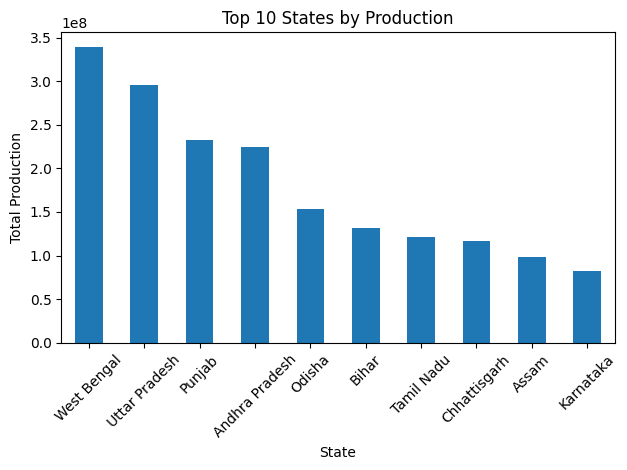

In [317]:
import matplotlib.pyplot as plt

# top states by total production
state_prod = df.groupby("state")["production"].sum().sort_values(ascending=False).head(10)

state_prod.plot(kind="bar")
plt.title("Top 10 States by Production")
plt.xlabel("State")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

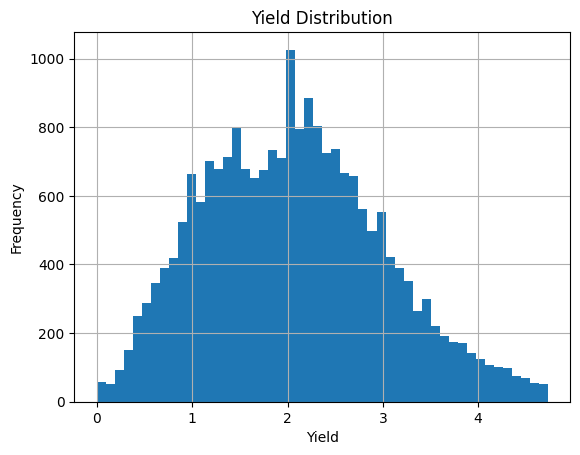

In [318]:
# distribution of yield
df["yield"].hist(bins=50)

plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

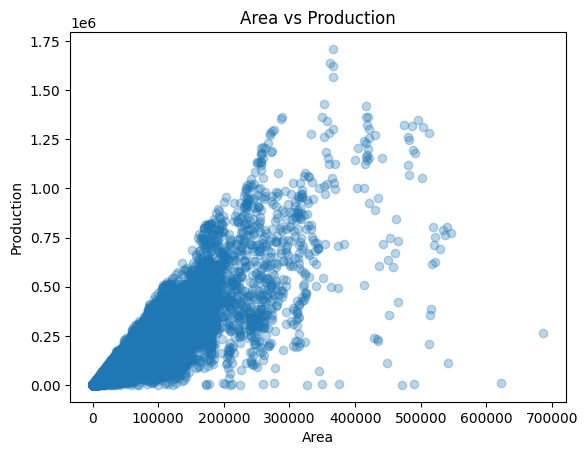

In [319]:
# relationship between area and production
plt.scatter(df["area"], df["production"], alpha=0.3)

plt.title("Area vs Production")
plt.xlabel("Area")
plt.ylabel("Production")
plt.show()

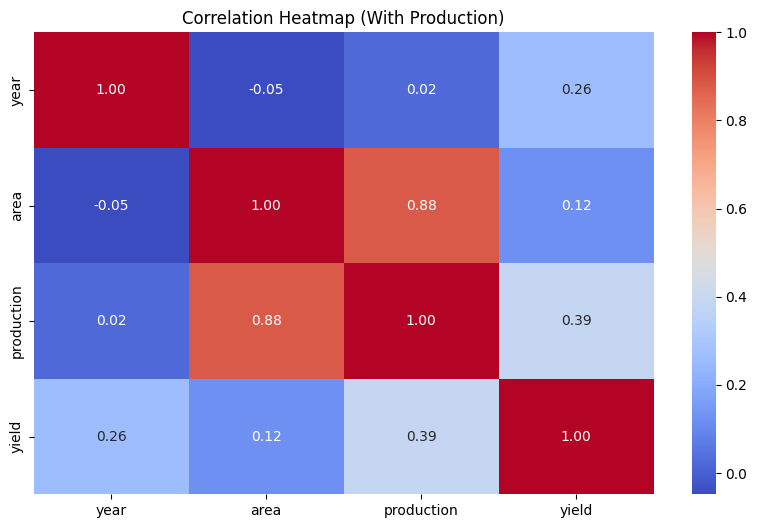

In [320]:
# copy dataset
df_corr = df.copy()

# drop only useless columns
df_corr = df_corr.drop(columns=["area_units", "production_units","state", "district", "season","crop"])

#encode categorical columns
#from sklearn.preprocessing import LabelEncoder

#cat_cols = ["crop"]

#for col in cat_cols:
    #le = LabelEncoder()
    #df_corr[col] = le.fit_transform(df_corr[col])

# correlation matrix
corr = df_corr.corr()

# plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap (With Production)")
plt.show()

In [321]:
# select input features and target variable
# removing yield (target) and unnecessary unit columns

X = df.drop(columns=["yield", "area_units", "production_units","production"], errors="ignore")
y = df["yield"]

In [322]:
from sklearn.model_selection import train_test_split

# split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [323]:
from sklearn.preprocessing import LabelEncoder

# encode categorical columns into numbers
#cat_cols = ["state", "district", "crop", "season"]

#for col in cat_cols:
    #le = LabelEncoder()
    #X_train[col] = le.fit_transform(X_train[col])
    #X_test[col] = le.transform(X_test[col])
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ["state", "district", "crop", "season"]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [324]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

In [325]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# predictions
rf_pred = rf.predict(X_test)

# metrics
r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)

# print results clearly
print("Random Forest Performance")
print("-------------------------")
print("R2 Score :", round(r2_rf, 4))
print("RMSE     :", round(rmse_rf, 4))
print("MAE      :", round(mae_rf, 4))

Random Forest Performance
-------------------------
R2 Score : 0.8095
RMSE     : 0.4105
MAE      : 0.2818


    Feature  Importance
0     state    0.412679
5      area    0.200003
1  district    0.146239
3      year    0.133969
4    season    0.107110
2      crop    0.000000


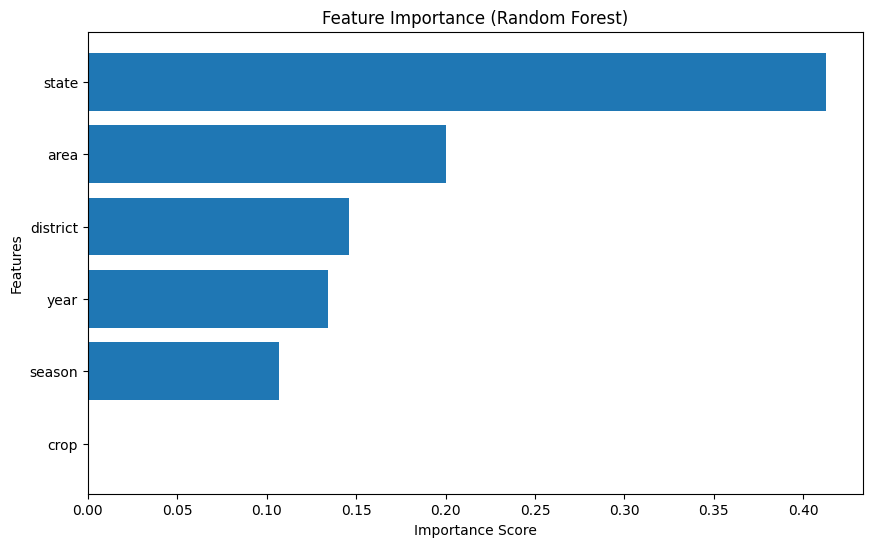

In [326]:
import pandas as pd
import matplotlib.pyplot as plt

# get feature importance values
importances = rf.feature_importances_

# create dataframe for better visualization
feat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# sort features by importance
feat_importance = feat_importance.sort_values(by="Importance", ascending=False)

# display top features
print(feat_importance)

# plot
plt.figure(figsize=(10, 6))
plt.barh(feat_importance["Feature"], feat_importance["Importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()